In [7]:
import os
import numpy as np
import json
from tqdm import tqdm
from dataset import process_dataset
from scaler import VitalScaler
from evaluate_alerting import evaluate_alert_hitrate, summarize_alert_hitrate

In [8]:
#1. Load and Process Data
train_df, test_df = process_dataset(test_mode=False) 

#Normalize Data and Save Scaler
print("loading datasets...")
scaler = VitalScaler()
scaler.fit(train_df)

loading datasets...


In [9]:
def get_full_evaluation_alerting_metrics(outputs_path):
    targets = ['HR', 'RESP', 'SpO2']

    alerts = []

    for batch_name in tqdm(os.listdir(outputs_path)):
        batch_path = f'{outputs_path}/{batch_name}'

        encoder_target = scaler.inverse(np.load(f'{batch_path}/encoder_target.npy'))
        decoder_target = scaler.inverse(np.load(f'{batch_path}/decoder_target.npy'))
        samples = np.load(f'{batch_path}/samples.npy')
        median_pred = np.median(samples, axis=0)

        for i in range(decoder_target.shape[0]):
            gts = encoder_target[i]
            preds = median_pred[i]
            for j in range(3):
                vital = targets[j]
                gt = gts[:, j]
                pred = preds[:, j]

                alert = evaluate_alert_hitrate(pred, gt, vital)
                alerts.append(alert)

    alerts_df = summarize_alert_hitrate(alerts)

# Base Model (pretrained vs non pretrained)

## Non Pretrained

100%|██████████| 567/567 [04:52<00:00,  1.94it/s]


=== Alert Hit Rate by Vital ===
         Hits   Total HitRate
Vital                        
HR     256513  290304   88.4%
RESP   102855  290304   35.4%
SpO2   193734  290304   66.7%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.89      1.00      0.94    241217
     warning       0.74      0.32      0.45     39896
   emergency       1.00      0.26      0.41      9191

    accuracy                           0.88    290304
   macro avg       0.88      0.53      0.60    290304
weighted avg       0.87      0.88      0.86    290304


--- RESP ---
              precision    recall  f1-score   support

      stable       0.16      0.95      0.28     23988
     warning       0.33      0.34      0.33     98791
   emergency       1.00      0.28      0.44    167525

    accuracy                           0.35    290304
   macro avg       0.50      0.52      0.35    290304
weighted avg       0.70      0.35      0.39 

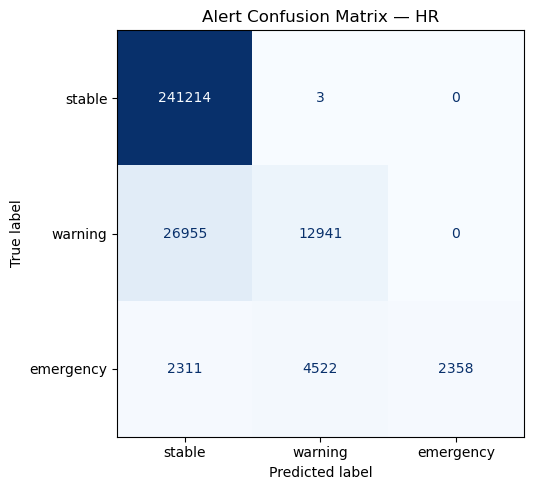

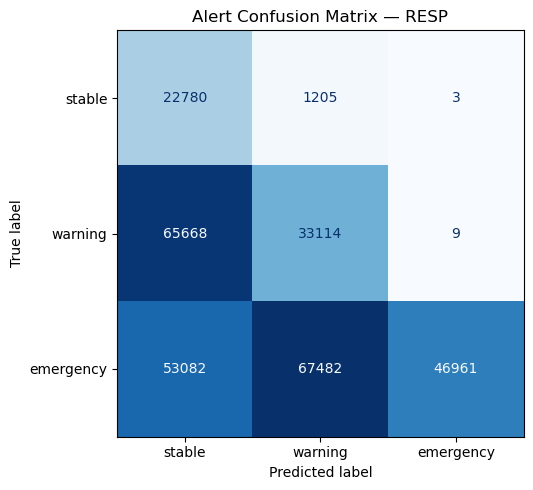

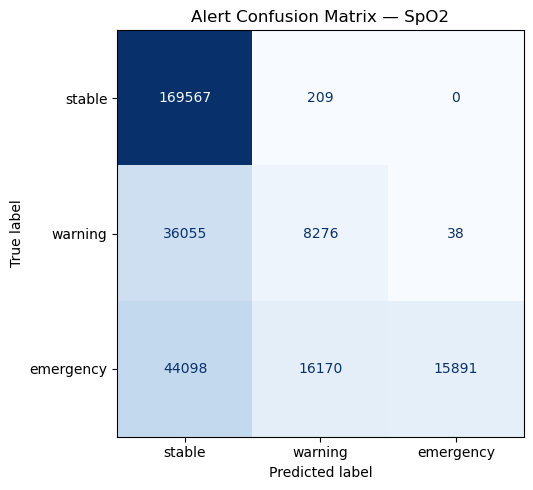

In [10]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)

## Pretrained

100%|██████████| 570/570 [04:56<00:00,  1.92it/s]


=== Alert Hit Rate by Vital ===
         Hits   Total HitRate
Vital                        
HR     264075  291840   90.5%
RESP   106858  291840   36.6%
SpO2   196313  291840   67.3%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.91      1.00      0.95    242489
     warning       0.83      0.45      0.58     40091
   emergency       0.99      0.40      0.57      9260

    accuracy                           0.90    291840
   macro avg       0.91      0.61      0.70    291840
weighted avg       0.90      0.90      0.89    291840


--- RESP ---
              precision    recall  f1-score   support

      stable       0.16      0.94      0.28     24109
     warning       0.34      0.36      0.35     99189
   emergency       1.00      0.29      0.45    168542

    accuracy                           0.37    291840
   macro avg       0.50      0.53      0.36    291840
weighted avg       0.71      0.37      0.40 

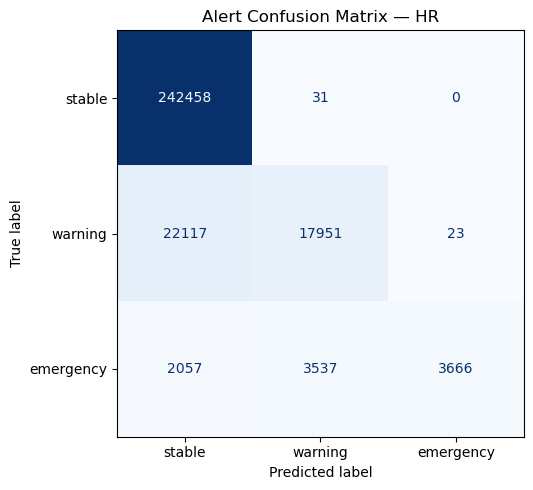

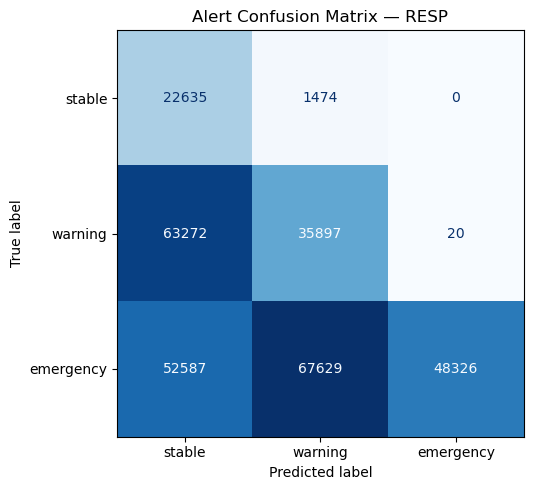

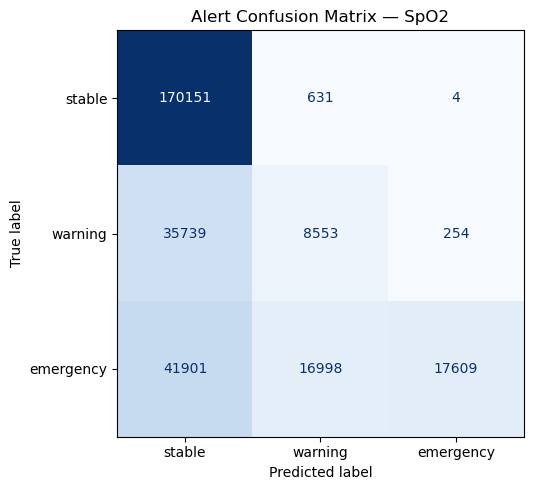

In [15]:
#testing variables
use_pretrained_vital_encoder_weights = True # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)

# Waveform Data (waveform conditioned vs non waveform conditioned)

## Non waveform Conditioned

100%|██████████| 73/73 [00:09<00:00,  7.57it/s]


=== Alert Hit Rate by Vital ===
       Hits  Total HitRate
Vital                     
HR     4367  18496   23.6%
RESP   4917  18496   26.6%
SpO2   8406  18496   45.4%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.25      1.00      0.41      4065
     warning       0.00      0.00      0.00      3360
   emergency       1.00      0.03      0.05     11071

    accuracy                           0.24     18496
   macro avg       0.42      0.34      0.15     18496
weighted avg       0.65      0.24      0.12     18496


--- RESP ---
              precision    recall  f1-score   support

      stable       0.00      0.00      0.00         0
     warning       0.02      1.00      0.04       123
   emergency       1.00      0.26      0.41     18373

    accuracy                           0.27     18496
   macro avg       0.34      0.42      0.15     18496
weighted avg       0.99      0.27      0.41     18496


---

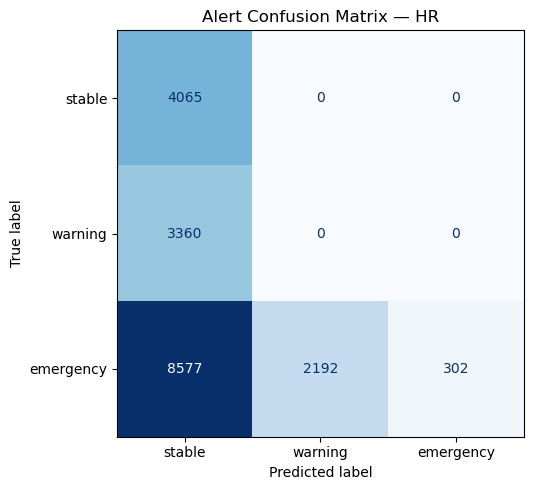

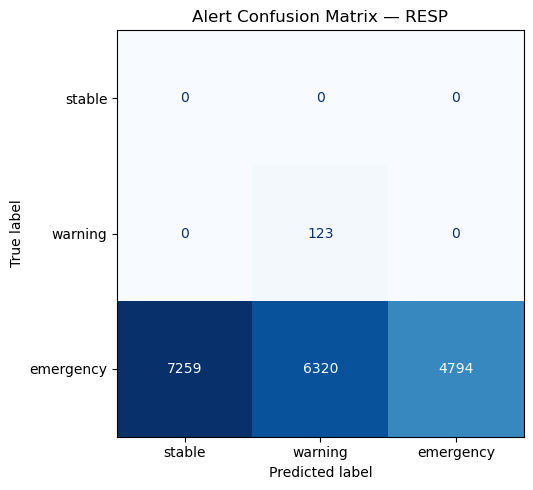

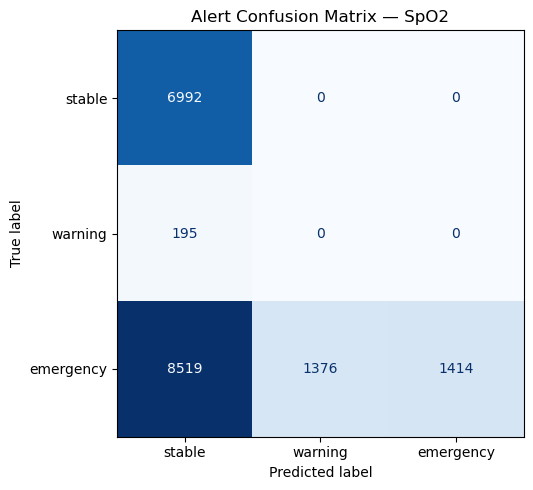

In [11]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = True # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)

## Waveform Conditioned

100%|██████████| 73/73 [00:09<00:00,  7.54it/s]


=== Alert Hit Rate by Vital ===
       Hits  Total HitRate
Vital                     
HR     4179  18496   22.6%
RESP   4795  18496   25.9%
SpO2   8756  18496   47.3%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.24      1.00      0.39      3812
     warning       0.00      0.00      0.00      3087
   emergency       1.00      0.03      0.06     11597

    accuracy                           0.23     18496
   macro avg       0.41      0.34      0.15     18496
weighted avg       0.68      0.23      0.12     18496


--- RESP ---
              precision    recall  f1-score   support

      stable       0.00      0.00      0.00       129
     warning       0.01      1.00      0.01        38
   emergency       1.00      0.26      0.41     18329

    accuracy                           0.26     18496
   macro avg       0.34      0.42      0.14     18496
weighted avg       0.99      0.26      0.41     18496


---

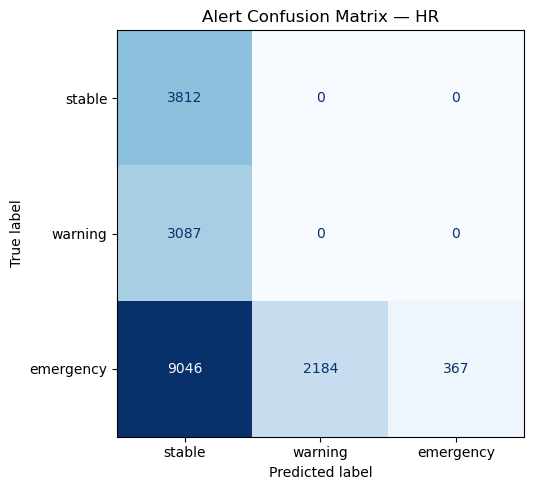

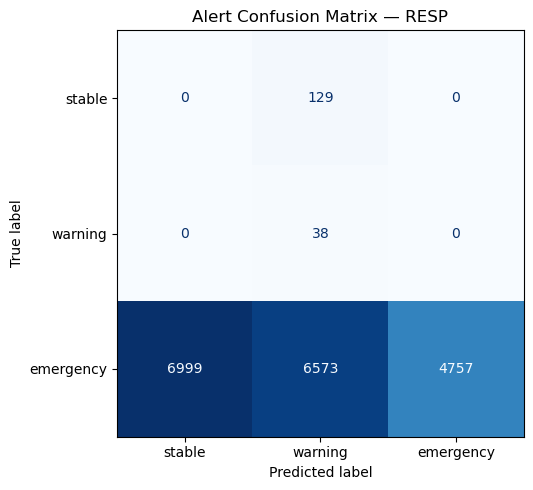

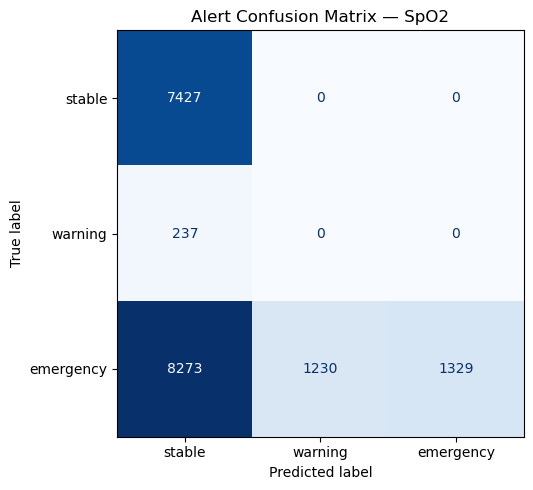

In [12]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = True # CHANGE
waveform_conditioning = True # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)

# Clinical Data (clinical conditioned vs non clinical condtioned)

## Non Clinical Conditioned

100%|██████████| 255/255 [01:02<00:00,  4.05it/s]


=== Alert Hit Rate by Vital ===
        Hits   Total HitRate
Vital                       
HR     25542  130525   19.6%
RESP   30141  130525   23.1%
SpO2   53956  130525   41.3%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.20      1.00      0.33     23251
     warning       0.00      0.00      0.00     26405
   emergency       1.00      0.03      0.06     80869

    accuracy                           0.20    130525
   macro avg       0.40      0.34      0.13    130525
weighted avg       0.66      0.20      0.09    130525


--- RESP ---
              precision    recall  f1-score   support

      stable       0.00      0.84      0.00        32
     warning       0.01      0.89      0.01       302
   emergency       1.00      0.23      0.37    130191

    accuracy                           0.23    130525
   macro avg       0.34      0.65      0.13    130525
weighted avg       1.00      0.23      0.37    13

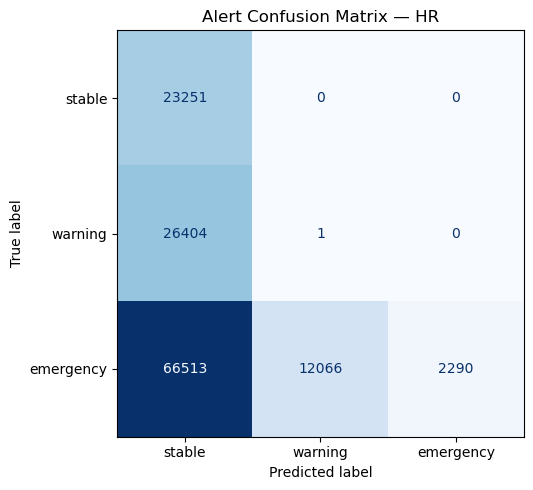

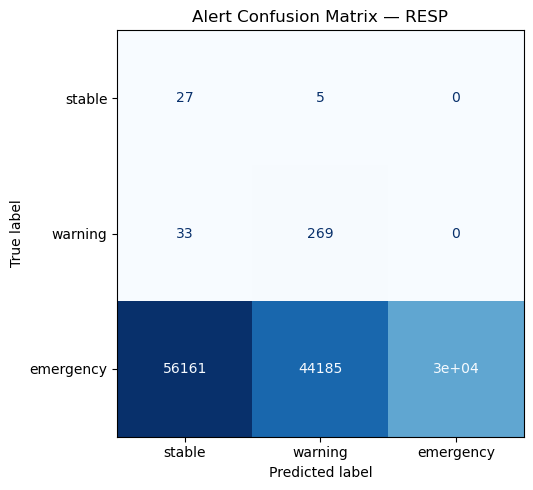

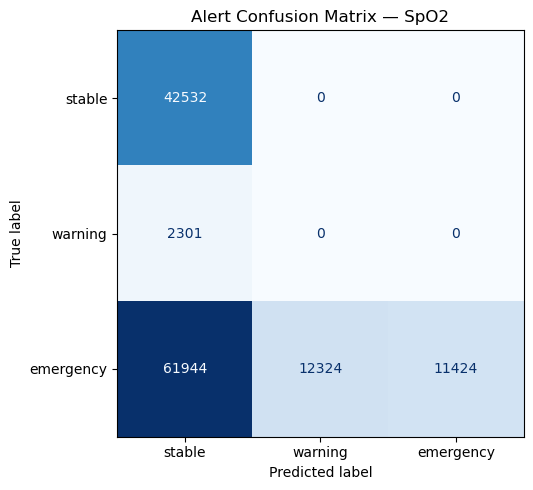

In [13]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = True  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)

## Clinical Conditioned

100%|██████████| 255/255 [01:03<00:00,  4.04it/s]


=== Alert Hit Rate by Vital ===
        Hits   Total HitRate
Vital                       
HR     25536  130525   19.6%
RESP   26664  130525   20.4%
SpO2   53308  130525   40.8%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.20      1.00      0.33     23251
     warning       0.00      0.00      0.00     26405
   emergency       1.00      0.03      0.05     80869

    accuracy                           0.20    130525
   macro avg       0.40      0.34      0.13    130525
weighted avg       0.65      0.20      0.09    130525


--- RESP ---
              precision    recall  f1-score   support

      stable       0.00      1.00      0.00        32
     warning       0.00      0.09      0.00       302
   emergency       1.00      0.20      0.34    130191

    accuracy                           0.20    130525
   macro avg       0.33      0.43      0.11    130525
weighted avg       1.00      0.20      0.34    13

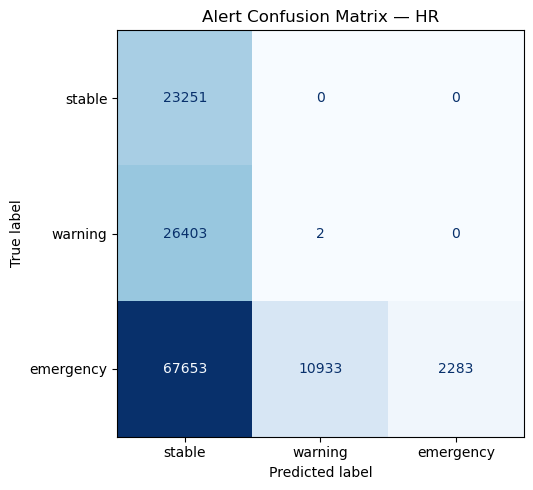

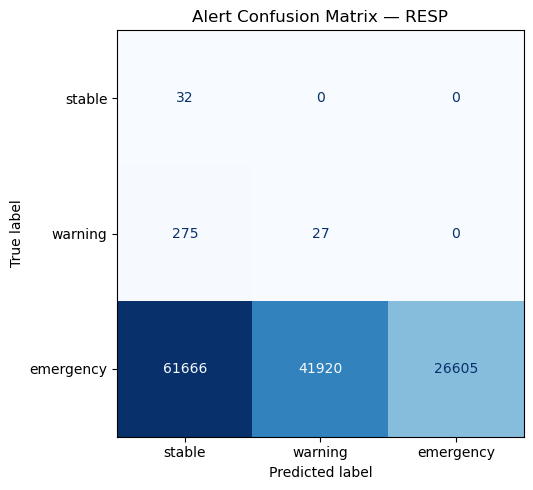

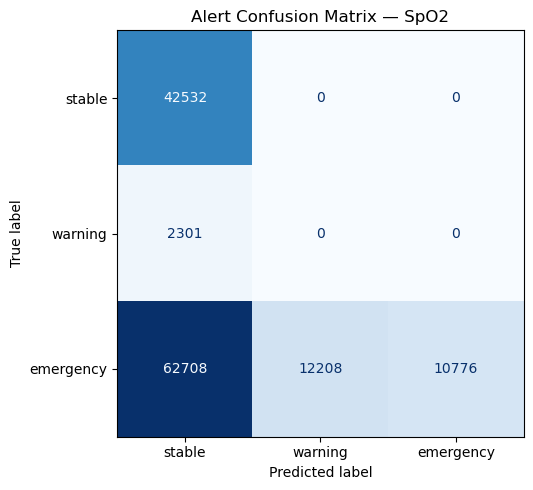

In [14]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = True  # CHANGE
clinical_conditioning = True  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_alerting_metrics(outputs_path)